[{'algorithm': 'LZ77',
  'compress_time': 7.939338684082031e-05,
  'compressed_size': 63,
  'compression_ratio': 1.8,
  'decompress_time': 1.0967254638671875e-05,
  'file': 'test1',
  'original_size': 35},
 {'algorithm': 'LZ78',
  'compress_time': 1.52587890625e-05,
  'compressed_size': 69,
  'compression_ratio': 1.9714285714285715,
  'decompress_time': 7.3909759521484375e-06,
  'file': 'test1',
  'original_size': 35},
 {'algorithm': 'LZW',
  'compress_time': 4.5299530029296875e-05,
  'compressed_size': 62,
  'compression_ratio': 1.7714285714285714,
  'decompress_time': 3.552436828613281e-05,
  'file': 'test1',
  'original_size': 35},
 {'algorithm': 'LZ77',
  'compress_time': 0.007850170135498047,
  'compressed_size': 4221,
  'compression_ratio': 1.6110687022900763,
  'decompress_time': 0.0006189346313476562,
  'file': 'test2',
  'original_size': 2620},
 {'algorithm': 'LZ78',
  'compress_time': 0.0006778240203857422,
  'compressed_size': 2528,
  'compression_ratio': 0.9648854961832061,

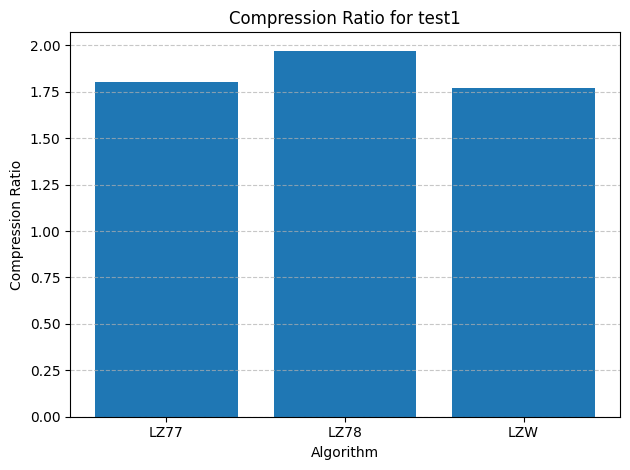

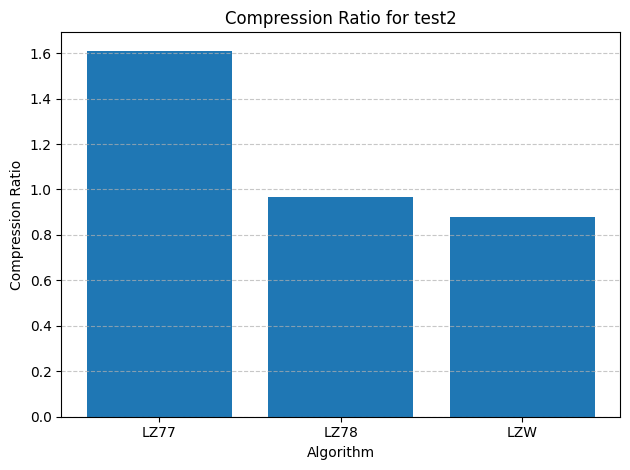

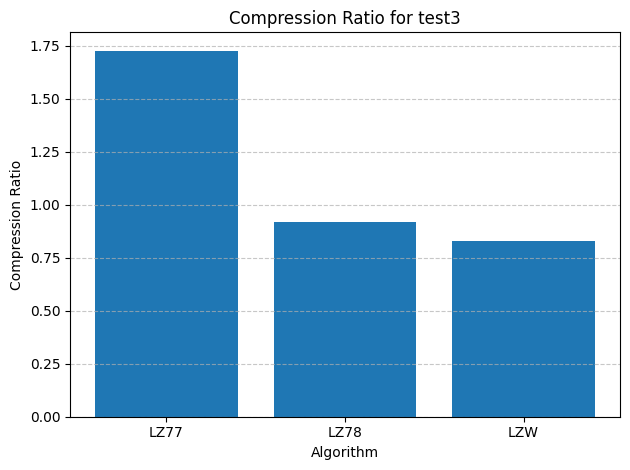

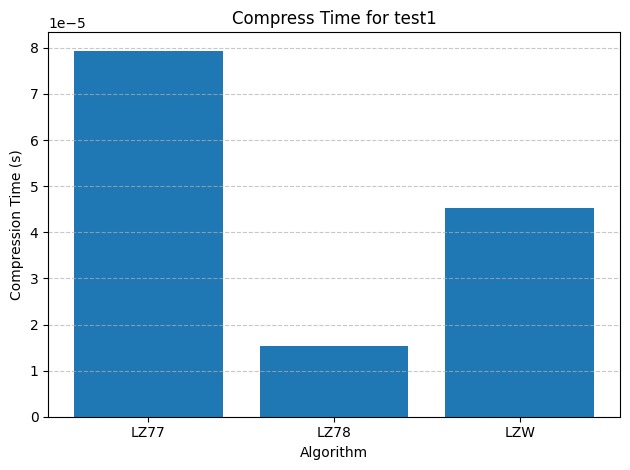

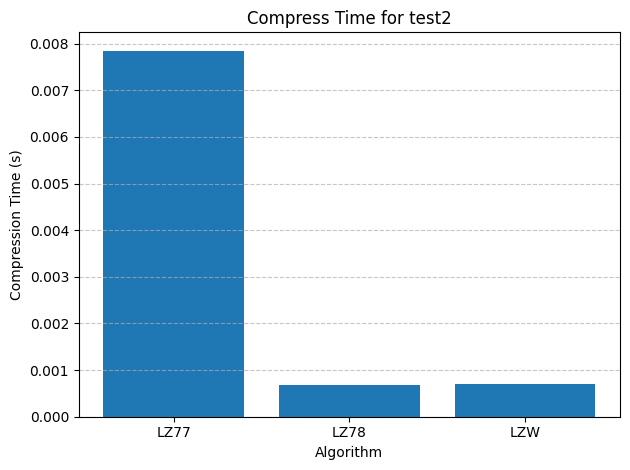

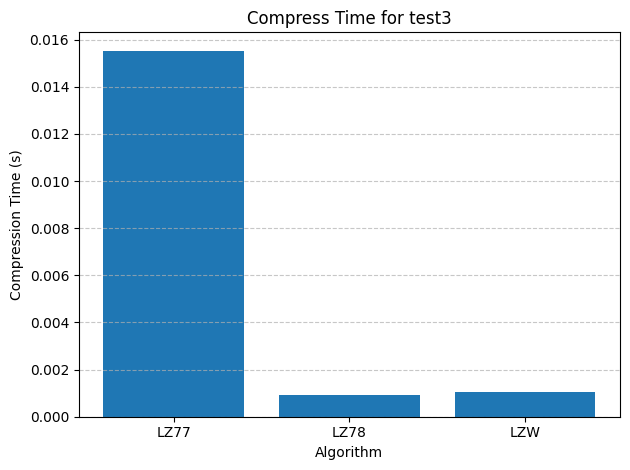

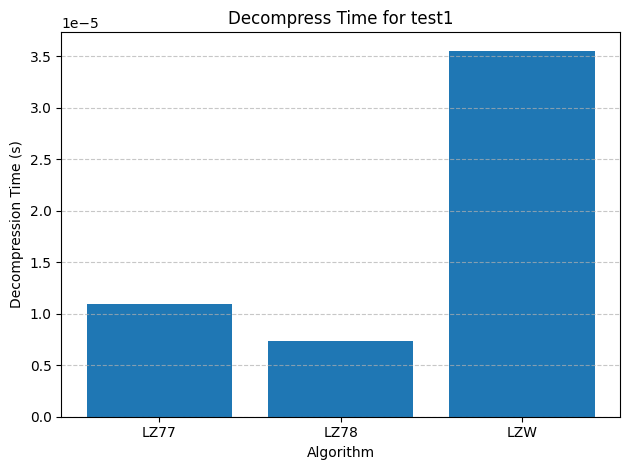

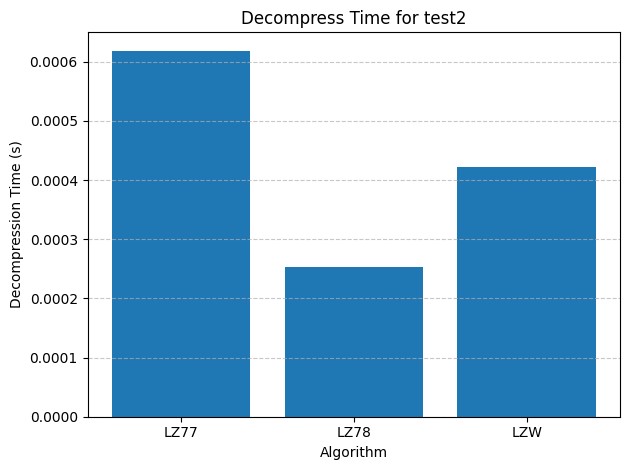

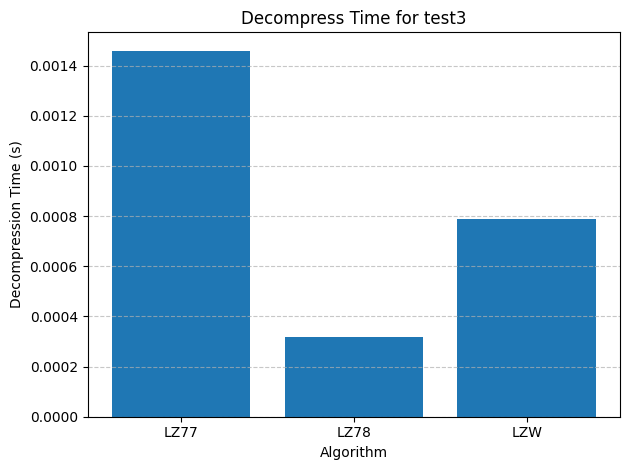

In [4]:
import time
import os
import matplotlib.pyplot as plt
import unicodedata

# --- LZ77 Implementation ---
def lz77_compress(data, window_size=20):
    i = 0
    output = []
    while i < len(data):
        match = (-1, -1)
        for j in range(max(0, i - window_size), i):
            length = 0
            while i + length < len(data) and data[j + length] == data[i + length]:
                length += 1
                if j + length >= i:
                    break
            if length > match[1]:
                match = (i - j, length)
        if match[1] > 0:
            output.append((match[0], match[1], data[i + match[1]] if i + match[1] < len(data) else ''))
            i += match[1] + 1
        else:
            output.append((0, 0, data[i]))
            i += 1
    return output

def lz77_decompress(compressed):
    decompressed = ""
    for offset, length, char in compressed:
        if offset == 0 and length == 0:
            decompressed += char
        else:
            start = len(decompressed) - offset
            for i in range(length):
                decompressed += decompressed[start + i]
            decompressed += char
    return decompressed

# --- LZ78 Implementation ---
def lz78_compress(data):
    dictionary = {"": 0}
    w = ""
    output = []
    dict_size = 1
    for c in data:
        wc = w + c
        if wc in dictionary:
            w = wc
        else:
            output.append((dictionary[w], c))
            dictionary[wc] = dict_size
            dict_size += 1
            w = ""
    if w:
        output.append((dictionary[w], ''))
    return output

def lz78_decompress(compressed):
    dictionary = [""]
    decompressed = ""
    for index, char in compressed:
        entry = dictionary[index] + char
        decompressed += entry
        dictionary.append(entry)
    return decompressed

# --- LZW Implementation ---
def lzw_compress(data):
    dict_size = 256
    dictionary = {chr(i): i for i in range(dict_size)}
    w = ""
    output = []
    for c in data:
        wc = w + c
        if wc in dictionary:
            w = wc
        else:
            output.append(dictionary[w])
            dictionary[wc] = dict_size
            dict_size += 1
            w = c
    if w:
        output.append(dictionary[w])
    return output

def lzw_decompress(compressed):
    dict_size = 256
    dictionary = {i: chr(i) for i in range(dict_size)}
    result = w = chr(compressed.pop(0))
    for k in compressed:
        if k in dictionary:
            entry = dictionary[k]
        elif k == dict_size:
            entry = w + w[0]
        else:
            raise ValueError('Bad compressed k: %s' % k)
        result += entry
        dictionary[dict_size] = w + entry[0]
        dict_size += 1
        w = entry
    return result

# --- Utility Functions ---
def read_file(path):
    with open(path, 'r', encoding='utf-8') as f:
        return f.read()

def normalize_text(text):
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')

def compression_stats(original, compressed, method_name):
    original_size = len(original.encode('utf-8'))
    if method_name == "LZW":
        compressed_size = len(compressed) * 2  # assuming 16-bit ints
    elif method_name == "LZ77":
        compressed_size = sum([2 + len(c[2].encode('utf-8')) for c in compressed])
    elif method_name == "LZ78":
        compressed_size = sum([2 + len(c[1].encode('utf-8')) for c in compressed])
    else:
        compressed_size = len(str(compressed).encode('utf-8'))
    ratio = compressed_size / original_size
    return original_size, compressed_size, ratio

def test_algorithm(name, compress_func, decompress_func, data):
    data = normalize_text(data)
    start = time.time()
    compressed = compress_func(data)
    compress_time = time.time() - start

    start = time.time()
    decompressed = decompress_func(compressed)
    decompress_time = time.time() - start

    assert decompressed == data, f"{name} decompression failed"

    original_size, compressed_size, ratio = compression_stats(data, compressed, name)

    return {
        "algorithm": name,
        "original_size": original_size,
        "compressed_size": compressed_size,
        "compression_ratio": ratio,
        "compress_time": compress_time,
        "decompress_time": decompress_time
    }

# --- Run Tests ---
files = {
    "test1": read_file("/content/drive/MyDrive/test1.txt"),
    "test2": read_file("/content/drive/MyDrive/test2.txt"),
    "test3": read_file("/content/drive/MyDrive/test3.txt"),
}

results = []
for fname, data in files.items():
    for name, comp, decomp in [("LZ77", lz77_compress, lz77_decompress),
                               ("LZ78", lz78_compress, lz78_decompress),
                               ("LZW", lzw_compress, lzw_decompress)]:
        result = test_algorithm(name, comp, decomp, data)
        result["file"] = fname
        results.append(result)

# --- Display Results ---
from pprint import pprint
pprint(results)

# --- Visualization ---
def plot_results(results, metric, ylabel):
    import matplotlib.pyplot as plt
    files = sorted(set(r['file'] for r in results))
    algorithms = ["LZ77", "LZ78", "LZW"]

    for file in files:
        data = [r for r in results if r['file'] == file]
        values = [r[metric] for r in data]
        plt.bar(algorithms, values)
        plt.title(f"{metric.replace('_', ' ').title()} for {file}")
        plt.ylabel(ylabel)
        plt.xlabel("Algorithm")
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

plot_results(results, 'compression_ratio', 'Compression Ratio')
plot_results(results, 'compress_time', 'Compression Time (s)')
plot_results(results, 'decompress_time', 'Decompression Time (s)')
